# Key Methods in Physical Geography
# Computing Practical 4: Spatial Analysis of Geographic Data

This is a Jupyter notebook running on the University of Edinburgh Noteable Service (https://www.ed.ac.uk/information-services/learning-technology/noteable/about). Notebooks are interactive documents that can contain computer code (Python for this course), text and images.

For some components in this notebook, data files will be used. Any data file that is used for plotting with this and other notebooks needs to be uploaded to the Jupyter server -- unless they are provided for you, or there are commands provided to download the files directly to the Jupyter practical folder.

### Key Learning Outcomes

- Reading and Plotting Raster Data: GeoTIFF files

- Comparing point (vector) and raster data

    - Overlaying point (vector) data on raster data
    - Interpolating from raster to a point location
    - Interpolating multiple points through batch processing
    - Analysing comparison 
        - Scatter plots
        - Descriptive statistics
        - Linear regression    

- Raster generation from irregularly spaced data

- (Hill)slope analysis

    - Finding gradients
    - Logical slicing
    - (Logically) Masking data in rasters
    
- Shapefiles and Rasters

    - Using a shapefile to mask a raster
    - Integrating thickness over a region to find volume 

- Reading and plotting 2D climate data: more with NETCDF files

## Reading and plotting raster data

We have learned how to read into python, extract data from, and analyse a very common type of GIS data format, shapefiles -- using the python library `geopandas`. Shapefiles describe *vector* data. We also learned how to read from netCDF4 files using `xarray`. Today we will see how to analyse another very common type of data format, *GeoTIFF* files (\*.tif or \*.tiff) files. (Tag Image File Format files, or TIFF files, are often used for images; GeoTIFF files have georeferencing encoded.) Geotiff files are a common file format used to store *raster* data, i.e. gridded data. 

We will work with a GeoTIFF file which contains a Digital Terrain Model (DTM) of Arthur's Seat at 2m horizontal resolution. The file is called `arthurs_seat.tif` and it has been included in your directory.

Begin by importing the library `rasterio`, but with the abbreviation `rio` as some suggested code below might depend on this abbreviation.

In [1]:
import rasterio as rio

We begin by using the function `rio.open` to open the geotiff file. This returns a variable (of type `DatasetReader`) which can be used to extract data from the geotiff. In terms of previous practicals, this DatasetReader is analogous to the `geodataframe` we encountered in week 7 and the `xarray.Dataset` we saw last week. The process is very similar: you will define a new variable (e.g. `geotiffreader`) and set this equal to `rio.open(filename)` where `filename` is the geotiff you wish to analyse. (Remember this needs to be a string, not a variable name.) 

In the following cell, use `rio.open()` to set a new `DatasetReader` to extract data from `arthurs_seat.tif`.

(Not as many commands will be given to you for copy and paste as in previous practicals -- this is to prepare you for your assessment. If it is not clear how to use the `open` function, please refer to the example in the week 7 practical under the heading "**Overlying on rasters**"
which opens the file `dem.tif`. The same applies for the following task as well.)

In [2]:
geotiffreader = rio.open('arthurs_seat.tif')

If `rio.open()` was called correctly you can now examine the properties of the geotiff. One obvious question is, what does the data look like? We can address this by extracting the data as a 2 Dimensional array. The `geotiffreader` variable (assuming you called it this) has a bespoke function `read` which can be used for this purpose. In the following cell, define a variable `z` to be equal to `geotiffreader.read(1)`. The argument `1` tells python to read only the *first layer* (even though the file contains only one layer). Without it, `z` would be a 3 Dimensional array and require more work to visualise.

In [3]:
z = geotiffreader.read(1)

Now we can visualise this DTM with the function `imshow`, which is part of the `matplotlib.pyplot` module. Import `matplotlib.pyplot` as `plt` and then type `plt.imshow(z)` in the next cell. 

BoundingBox(left=326400.0, bottom=674400.0, right=328900.0, top=676900.0)


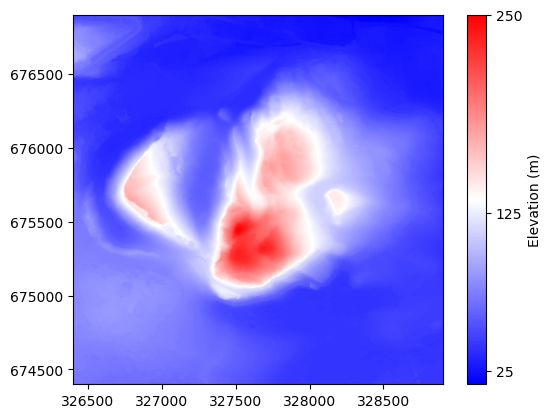

In [15]:
import matplotlib.pyplot as plt

bounds = geotiffreader.bounds
top = bounds.top
bottom = bounds.bottom
left = bounds.left
right = bounds.right

plt.imshow(z,cmap='bwr', extent=(left, right, bottom, top))
cbar = plt.colorbar()
cbar.set_label('Elevation (m)')
cbar.set_ticks([25,125,250])

print(bounds)

You should see a color image of a top down view of Arthur's seat. However, there is not much information given. 

*In the following exercises you will make changes to the figure above. You might wish to modify the cell above, or create new cells below this one by clicking the "Insert cell" button on the Notebook menu bar -- just below "File"*.

<span style="color:blue">**Adding a colorbar.**</span> 

Firstly, there is no colorbar. This can be added with the command

```python
cbar = plt.colorbar()
```

`cbar` is a "handle" to the colorbar which can be used to modify it further (and can have a different name). Modify the figure above to have a colorbar and run it again.

You can further modify the colorbar using `cbar`. For instance `cbar.set_label()` allows you to label the colorbar by providing a string as an argument. `cbar.set_ticks()` can change the tick locations on the colorbar and takes a *list* of locations as an argument. Modify the code further to add the colorbar label 'Elevation (m)' and only have ticks at 125 and 250 m.

<span style="color:blue">**Changing the colour map.**</span> 

The colour map (but python spells it **color**!) determines which color corresponds the value in each pixel. By default the color map is `'viridis'` but you can change this as `imshow` has an **optional argument** (a *kwarg*) `cmap`. Recall: when a function has an **optional argument**, we must reference this argument *by name* (e.g. `cmap=...`) within the brackets of the function call. In the figure above, can you change the color map to the rainbow scale `'jet'`? (Note, the name of the color map must be in quotes.) Experiment with a few color maps listed [here](https://matplotlib.org/tutorials/colors/colormaps.html) (you need to scroll down to see the choices). How does Arthurs Seat appear with a seismic color map? (**Tip**: when dealing with data that can be positive or negative, diverging colormaps are good to use -- but only if configured if their "diverging" point coincides with zero!)

<span style="color:blue">**Changing axis georeferencing.**</span> 

The x- and y-axis ticks are not in terms of physical distance, but rather in terms of *pixel count*. (e.g. where it says "1200" on the x-axis, this is the position of the 1200th column of the raster.) This is not helpful for comparing with features on other maps, or with other measurements of elevation. 

This is addressed in `imshow` with the kwarg `extent`. This is used (within the brackets of the `imshow` command) as 

```python
extent = (left, right, bottom, top)
```

where `left` is the leftmost extent of the raster in its geographic coordinate system, `right` is the rightmost extent, etc. **But how do we know the geographic extent of the raster file?** In e.g. QGIS these are properties we can look up in a table when we load a GeoTIFF. In python we can do something similar. Our variable `geotiffreader` which we used to extract the array also contains these bounds in the property `geotiffreader.bounds`. In the cell below, type `print(geotiffreader.bounds)` to see what these are.

Use the `extent` optional argument to have the x-labels show proper geographic positioning. You can modify the axes to show the correct georeferencing in one of two ways: (1) add the optional `extent` argument as described above by typing the numbers you see below in place of `left`, `right`, etc. or (2) previous to the `imshow` command, define the variables

```python
figTop = geotiffreader.bounds.top
figBottom = geotiffreader.bounds.bottom
```

and so on, and then adding the optional `extent` argument with these variables in place of actual typed numbers. Methods (2) is better practice -- as this code can be reused for a different GeoTIFF with different extents.

The GeoTIFF format is unique in that the **top** left corner is treated as the "reference" location, and `imshow` is specifically designed for this. Using `imshow` with any other format, e.g. a 2D netCDF raster, would require adjusting the `origin` keyword argument (*kwarg*), as shown in the exercise at the end of the practical.

This also means that `z[0,0]`, which is the value of the **first row and first column** of `z`, corresponds to the **top left corner** of the image. This makes things slightly confusing below, when we create georeferencing arrays for the positions of the rows and columns.

<span style="color:blue">**Labelling axes.**</span> 

Labelling of the x- and y-axis works exactly has it has before. Label the axes "x (m)" and "y (m)" . *How do we know they are in meters? See below*

<span style="color:blue">**Geographic coordinate reference system**.</span> 

No more changes to the current figure are required (though we have lots more to do!) but we should be aware of the **coordinate reference system** used in the GeoTIFF. This is a concept that you should have learned about in the context of GIS -- different data can be referenced to different *grids* -- latitude/longitude, Polar Stereographic, Universal Transverse Mercator (UTM), etc. When we want to compare data in different coordinate systems, we need this information. For instance, data posted in UTM can easily be transformed to lat-lon coordinates using a number of python functions.

We can find the coordinate reference system (CRS) by examining `geotiffreader.crs` -- if we `print(geotiffreader.crs)` we see that the CRS is EPSG.27700. We would need to look this up but it is the British National Grid (that used by the Ordnance Survey). 

In [8]:

print(geotiffreader.bounds)
print(geotiffreader.crs)
print(geotiffreader.crs.linear_units)

BoundingBox(left=326400.0, bottom=674400.0, right=328900.0, top=676900.0)
EPSG:27700
metre


## Comparing point (vector) and raster data

During COVID, a handful of KMPG students trekked through Holyrood park for a little 'in-person' activity, with GPS devices to measure location and elevation. 

There is a .csv file in your practical folder titled `arthurs_gps.csv` with data columns $X$, $Y$, and $elev$. In the following cell, using similar techniques to those learned in week 6, read the data from the file into a pandas dataframe `gps_data`. Just as before, you can then type `gps_data` to see the contents, or you can also type `print(gps_data.keys())` to see just the header names. 

In [10]:

import pandas as pd
gps_data = pd.read_csv('arthurs_gps.csv')
gps_data.keys()


Index(['X', 'Y', 'elev'], dtype='object')

### Overlaying point (vector) data on raster data

The easiest way to visually compare the GPS and raster data is by overlaying a plot of the point data on the raster. In the following cell, create a raster plot of elevation as you did above (with correct georeferencing using `extent`). 

In the same cell, immediately after the raster, create a **scatter plot** of the gps data -- this should plot on the same figure, over the raster. You encountered `plt.scatter()` before, in Week 6. Do you remember how to set the colour of the markers? (It is the kwarg `c`.) Set the color according to the `elev` column.

For plotting scattered data over a raster, the best type of marker is a circle -- which is set by default, you do not need to use the `marker` kwarg. But it looks nicer if each circle has a clear boundary -- for this you can use the `edgecolor` kwarg (i.e. set it equal to `'k'`). Make sure as well that the `cmap` kwarg is the same colormap as for `imshow`! (i.e. if you use a jet colormap for imshow, use `cmap='jet'` in the scatter plot command too.)

If done correctly, you should see a raster plot of elevation, with small filled circles whose color indicates the value from the GPS measurement, not the raster. From this you can visually gauge the level of agreement. (You can also change the markers from circles to e.g. squares if you like -- see [the documentation](https://matplotlib.org/3.1.1/api/_as_gen/matplotlib.pyplot.scatter.html).)

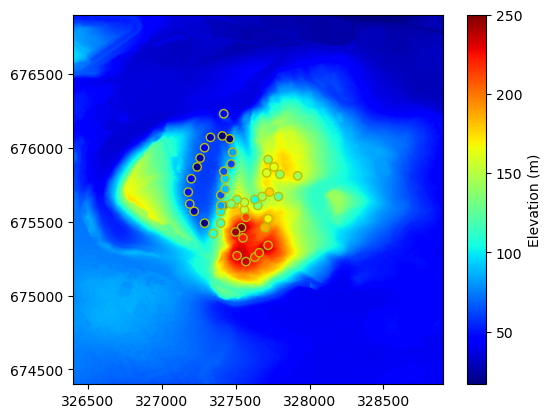

In [19]:
plt.imshow(z, cmap='jet', extent=(left, right, bottom, top))
cbar = plt.colorbar()
cbar.set_label('Elevation (m)')

plt.scatter(gps_data.X, gps_data.Y, c=gps_data.elev, cmap = 'jet', edgecolor='y');


However, we can make a more quantitative comparison. We are going to use the GPS data to see how to interpolate raster data to specific point locations. Such operations can be extremely usefule in geography dissertations, e.g. interpolating climate data to a specific location for comparison with a weather station. 

<span style="color:red">Unfortunately `rasterio` does not include a good function for interpolation, so we will need to do it a bit more.. manually -- that is, by using more basic Python functionality. The extra work we do, though, will help us with another task below. At the moment, we are interpolating from a gridded product to irregularly spaced points. Later on we will interpolate from irregularly spaced data to a grid -- a far more powerful tool (as data is generally gathered irregularly.)</span>

### Interpolating from raster to a point location

In order to interpolate DTM values to the locations in the .csv file, we need additional structures: NumPy arrays describing the coordinates of the raster grid. With a netCDF file these structures would be provided -- but for a GeoTIFF we need to create them ourselves.

That is, we need an array that contains the $y$-positions of all *rows* in the raster, and an array that describes the $x$-positions of all *columns* in the raster. For this we can use the `arange` function. In the cell below, `Y_array`, the array describing the positions of all *rows* is generated. There are several things to note about this: 

(1) We use the bounds of the raster file as the lower and upper bounds of this array.

(2) Since the reference coordinate of the GeoTIFF is the top left corner, we start with top and end with the bottom -- but the step is equal to **-2**, not 2, even though there is a 2m spacing.

**This consideration must only be made for GeoTIFF data and not for other types of data, such as NetCDF**.

(3) The beginning of the range in `np.arange` is offset by 1 meter. Remember that the raster is composed of 2m pixels. We also know (though it is buried deep in the metadata) that the data locations are in the *centre* of the 2m x 2m pixel. The first position we use is actually the top of the highest pixel. The centre of the pixel is offset 1 metre from this.

(4) To generate the array of X positions, you need to start with the leftmost position, offset by 1m, with a spacing of +2m.

In [21]:
# this is imported because we have not yet done so in this notebook!!!
import numpy as np

# arange starts with top-1.0 and does not include bottom, so ends at bottom+1.0, the center
# of the bottom pixel
Y_array = np.arange(geotiffreader.bounds.top-1.0,geotiffreader.bounds.bottom,-2.0);

# your code to generate X_array -- the array of column positions. 
# should start from the left position, offset by 1.0 (left+1.0), and go to the 'right' position
# with a spacing of 2.0
X_array = np.arange(geotiffreader.bounds.left+1.0, geotiffreader.bounds.right,2.0);

Now we are ready to interpolate. To begin, import `interp2d` from the module `scipy.interpolate` in the cell below -- it is the function we will use.

In [22]:
from scipy.interpolate import interp2d

Interpolation is still unfortunately a two-step process, illustrated in the cell below. In the first step, we use the position arrays `X_array` and `Y_array` together with the raster data elevation array `z` to create an **interpolant** -- a new *function* which can then produce interpolated values of elevation for *any* set of coordinates. The line of code looks like this:

```python
interper = interp2d(X_array,Y_array,z)
```

In the above, `interp2d` is called with 3 arguments -- the grid coordinate arrays `X_array` and `Y_array`, and the raster array `z`. There are additional optional arguments describing the *type* of interpolation (`'linear'`,`'cubic'`, or `'quintic'`). We will use the default, `'linear'`. 

`interper` is then a variable which is set equal to the result of `interp2d`. Here is where it becomes confusing -- this *variable* is a **function**!!. It is a bespoke function -- with a name we choose ourselves -- which can then be used to find the interpolated values of any coordinates we query. The function is structured this way so that each time we have new coordinates to interpolate, the results are found by Python a little bit faster.

In the second step below, we provide our **first** GPS point position to `interper` and assign the result to a new variable, `interp_elev0`. The interpolated and measured values are then printed.

Make sure you understand this code. Modify it to interpolate e.g. the 20th position in the .csv file, and compare this against the 20th measurement.

In [23]:
interper = interp2d(X_array,Y_array,z)

# what are the arguments for interper?
interp_elev0 = interper(gps_data.X[0],gps_data.Y[0])

print('interpolated value: ' + str(np.round(interp_elev0,1)))
print('measured value: ' + str(np.round(gps_data.elev[0],1)))      

interpolated value: [57.4]
measured value: 78


/tmp/ipykernel_87/1186816856.py:1: DeprecationWarning: `interp2d` is deprecated!
`interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.13.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  interper = interp2d(X_array,Y_array,z)
/tmp/ipykernel_87/1186816856.py:4: DeprecationWarning:         `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.13.0.

        For legacy code, nearly bug-for-bug compatible replacements are
        `RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
        scattered 2D data.

        In new code, for regular grids use `Regu

### Batch processing for entire excel file.

Hopefully you see the problem -- we don't want to do this 49 times!!! This is a job for **batch processing**. We are going to use a for-loop!

In order to end up with an array of interpolated values the same size as the columns in the .csv file, there is a new technique required -- creating an *empty* array. We have seen how to create arrays with `np.arange` but this is for a bespoke purpose -- we might want an array to be a placeholder for values not yet calculated. This is done with `np.empty`. It means the array is created, but the contents are meaningless (the values could be zero, or a billion -- the point is they are meaningless until we assign them).

For instance, to create an empty array `interp_elev` of size 49, the number of gps points, we type:

```python 
interp_elev = np.empty(49)
```

In the following cell, `interp_elev` is created with `np.empty`. It is an array 49 elements long -- one for every row of the csv file. Essentially, for each `i`, we want to interpolate elevation using `interper` at the `i`th GPS location.

In the cell, `interp_elev[0]` is set to the interpolated raster value at `(gps_data.X[0],gps_data.Y[0])`. We could copy and paste this, 48 times, changing the 0 to a 1, 1 to a 2, or so on. This is manageable for a short csv file like this -- but what about a much longer one?

.. we could use a for loop. Recall how for-loops are constructed. Write a for-loop in the follwing cell that, for each `i`, interpolates elevation using `interper` at the `i`th GPS location, and assigns the `i`th value of `interp_elev` to this result.

In [28]:
interp_elev = np.empty(49)
interp_elev[0] = interper(gps_data.X[0],gps_data.Y[0])

# here: define a for-loop that sets interp_elev[i] to interper(gps_data.X[i],gps_data.Y[i]) for i=0,1,2,....48.    
for i in range(49):
    interp_elev[i] = interper(gps_data.X[i], gps_data.Y[i])

/tmp/ipykernel_87/1574350272.py:2: DeprecationWarning:         `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.13.0.

        For legacy code, nearly bug-for-bug compatible replacements are
        `RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
        scattered 2D data.

        In new code, for regular grids use `RegularGridInterpolator` instead.
        For scattered data, prefer `LinearNDInterpolator` or
        `CloughTocher2DInterpolator`.

        For more details see
        `https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  interp_elev[0] = interper(gps_data.X[0],gps_data.Y[0])
/tmp/ipykernel_87/1574350272.py:6: DeprecationWarning:         `interp2d` is deprecated!
        `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.13.0.

        For legacy code, nearly bug-for-bug compatible replacements are
        `RectBivariateSpline` on regular grids, and `bisp

### Scatter plot comparison

If done correctly, `interp_elev` should contain interpolated values corresponding to the GPS coordinates, and these can be compared against the measured values in a scatter plot. In the cell below, create a scatter plot (using `plt.scatter`) with `interp_elev` on the x-axis and `gps_data.elev` on the y-axis. (No need to format the figure.. unless you want to!)

What would the figure look like if there were was perfect agreement in the measurements? To help guide an assessment of measurement error, plot a straight line in the figure as well. This can be done by adding

```python
plt.plot(interp_elev,interp_elev)
```

in the same cell. Given an eyeball estimate of how accurate the measurements are.

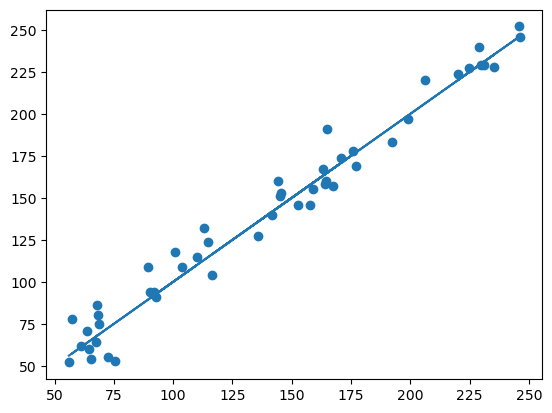

In [29]:
plt.scatter(interp_elev, gps_data.elev)
plt.plot(interp_elev,interp_elev);

### Descriptive statistics of error

We can be a bit more accurate in terms of assessing measurement accuracy. Firstly, we can define the error with a new valuable, `gps_error = gps_data.elev - interp_elev`. In the following cell, define `gps_error` and find its mean and standard deviation.

Though this data is a bit conjured, it is still important to remember that the error due to measuring elevation with GPS is due both to the error in one's horizontal position (which is small) as well as the error in measuring elevation (which is large).

In [30]:
gps_error = gps_data.elev - interp_elev

print('mean of error: ' + str(np.round(np.mean(gps_error),1)))
print('stdev of error: ' + str(np.round(np.std(gps_error),1)))

mean of error: 1.8
stdev of error: 10.4


### Linear regression

#### Note, this is somewhat of a review on linear regression from week 8. Skip if you now feel comfortable with linear regression.

We can also use linear regression to fit a **line** to this scatter plot, describing the gps-measured elevation as a **function** of raster elevation:

\begin{equation}
\mathrm{GPS\ Elevation} = m \times \mathrm{Raster\ Elevation} + c
\end{equation}

In the language of linear equations, $m$ is the *slope* of the line, and $c$ is the intercept. 

We can do this with the function `scipy.stats.linregress`. This function is called as follows:

```python
m,c,r,p,_ = linregress(x,y)
```

where `x` is what is commonly known as the *independent variable*, i.e the variable that explains `y`, the *dependent variable*. In the present case we are treating the ground GPS measurements as the dependent variable (although in many applications the situation is reversed -- with the ground measurements treated as the independent variable and the far less certain remotely sensed measurements treated as the dependent variable). `m` and `c` correspond to the slope and intercept, while `r` is the *correlation* between the two data sets, and `p` is the *significance*. A correlation is considered *strong* if it is close to 1 (or -1), and is considered *significant* if `p` is less than 0.05. (For more details, see the file correlation.pdf in this week's Learn folder.)

In the follow cell, import `linregress` from `scipy.stats` and find the linear regression between `interp_elev` and `gps_data.elev`. What are the slope and the intercept? What is the correlation and its significance (p-) value?

In [31]:
from scipy.stats import linregress

m,c,r,p,_ = linregress(interp_elev,gps_data.elev)

print(m)
print(c)
print(p)
print(r)


0.990244638292463
3.1649271499123586
2.994316584315197e-37
0.9845936108761446


## Raster generation from irregularly spaced measurements

Here we have started with a gridded DTM (`arthurs_seat.tif`). But in fact, these gridded products are derived from irregularly spaced data. Let us pretend that we *only* have our GPS data and try to derive a gridded raster product.

We can do this with the function `scipy.interpolate.griddata`. `griddata` is similar to `interp2d` in that it interpolates data -- but rather than interpolating from a gridded data set to a point, it interpolates from *irregularly spaced points* to a grid.

`griddata` is called as:

```python
gridded_elev = griddata((x_points,y_points),point_data,(X,Y))
```

where `x_points` and `y_points` are the coordinates of the irregularly spaced data, with `point_data` the corresponding values. 

`X` and `Y` are coordinates describing a grid -- where `X` is the position of the columns, and `Y` is of the rows. The arrays you created for interpolation, `X_array` and `Y_array`, are *almost* suitable for this, but `griddata` expects 2 dimensional arrays describing the grid to which we interpolate. This is addressed by `numpy.meshgrid`:

```python
X_array_2d, Y_array_2d = np.meshgrid(X_array,Y_array)
```
takes as input the 1-D arrays `X_array` and `Y_array` describing column and row positions, and returns 2D arrays `X_array_2d`  and `Y_array_2d`, which are now gridded values of $x$ and $y$ positions, respectively -- for every pixel location in the elevation raster, `X_array_2d` and `Y_array_2d` describe its position.

In the following cell, produce a gridded data product from the .csv data using `griddata`, by creating 2D arrays of $x$ and $y$ coordinates with `meshgrid`, and then calling `griddata`. In the example of `griddata` above, the variables are given different names than the ones you will likely use in your function call. Can you figure out which variables to use where?

In [32]:
from scipy.interpolate import griddata

X_array_2d, Y_array_2d = np.meshgrid(X_array, Y_array)

gridded_elev = griddata((gps_data.X, gps_data.Y), gps_data.elev, (X_array_2d, Y_array_2d), method='cubic')

if done correctly, `gridded_elev` is now a 2D array that can be plotted as a raster, just like `z`. To compare them side by side, we need to learn how to create **subplots**. To create subplots, we begin with the call 

```python
plt.subplots()
```

This id done for you below, and the `figsize` kwarg is used to control the size of the figure. Let's have 2 figures side by side. This means the next command should be

```python
plt.subplot(121)
```

This tells matplotlib that we are going to have 1 **row** of columns (the first "1"), and two **columns** ("2"). The last "1" indicates that we are about to draw the first figure.

If, immediately below this, we place code to draw a figure, it will correspond to the first figure. Plot (again) the elevation raster `z` with `plt.imshow()` as you did before. (colormap is up to you.)

Now, in the same cell, add the second subfigure, by calling `plt.subplot(122)`, where the second "2" indicates the second subplot. Here, create a near-identical figure, but plot `gridded_elev`, the array created with `griddata`, rather than `z`.

/tmp/ipykernel_87/1032904100.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(121)


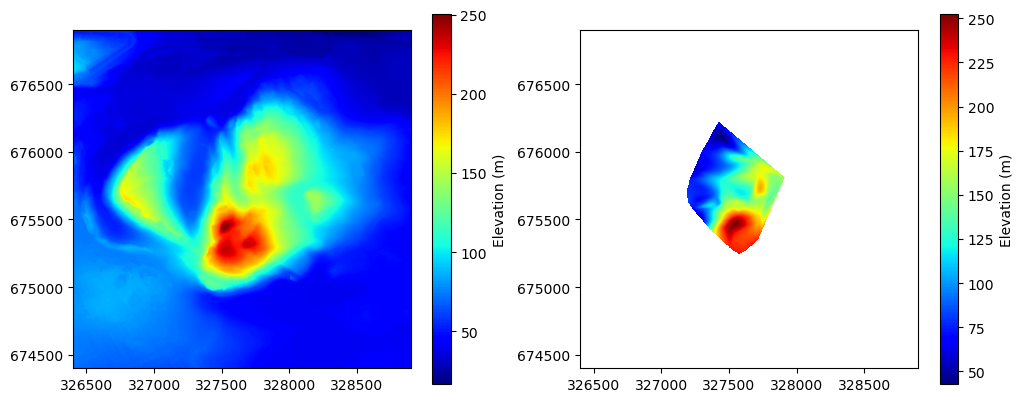

In [33]:
plt.subplots(figsize=(12,12))

plt.subplot(121)
plt.imshow(z, cmap='jet', extent=(left, right, bottom, top))
cbar = plt.colorbar(shrink = .4)
cbar.set_label('Elevation (m)')

plt.subplot(122)
plt.imshow(gridded_elev, cmap='jet', extent=(left, right, bottom, top))
cbar = plt.colorbar(shrink=.4)
cbar.set_label('Elevation (m)')

The figures are likely smaller than you would like -- and the colorbars too large. 

We can make the plots larger on screen by passing the optional argument `figsize` to `subplots()` e.g. `plt.subplots(figsize=(5,10))`. We can also resize the colorbars by passing the optional argument `shrink` to `colorbar()` e.g. `colorbar(shrink=.2)`. (The smaller the value, the smaller the colorbar.) Experiment with `figsize` and then `shrink` to get an image that you like. 

Now compare the GeoTIFF raster to the one we created by (synthetic) point measurements. There is a lot of empty grid -- mainly because the measurements did not cover a wide enough area. (In the future if the whole cohort is involved, we can map out the entire park!)

Where there are values, how accurate does it appear? There is an additional optional argument for `griddata` called method -- for **method of interpolation**. There are three methods: `'linear'`,`'cubic'`, and `'nearest'` (nearest neighbour). How does each affect the figure on the right above?

## Hillslope Analysis

In many cases analysis of a spatial data set involves determining how quickly it is changing as one moves across it i.e. its *variability*. One measure of how much terrain varies is the **slope** of a DTM. With our NumPy tools this is something we can investigate easily by finding its **gradient**:

```python
gradeEast, gradeNorth = np.gradient(z, dx)
```

here `dx` is the spacing of the raster pixels -- in the present case, 2. `gradeEast` is the *grade*, or *slope* in terms of rise over run, in the Eastward direction at each pixel, and similarly for gradeNorth.

However, the direction in which the slope is steepest may not be either east or north! We find this "steepest slope" at each pixel with the formula

\begin{equation}
\mathrm{grade} = \sqrt{gradeEast^2 + gradeNorth^2}
\end{equation}

However, spatial analysts are less concerned with "rise over run" and more with slope *angle*, the angle of ascent (or descent) of a slope. Once you have calculated *grade*, try to calculate the slope angle. You might recall `np.arctan()` which will be useful! However, `np.arctan()` gives results in radians, and we want degrees -- apply `np.rad2deg` to the result to get a 2 Dimensional array of slope angle in degrees.

Use `imshow` to visualise this slope angle. A lot of detail is missing though because of some very steep isolated regions (angles of up to 80 degrees). We can change the limits of the raster plot by passing two additional optional arguments to `imshow`: `vmin` and `vmax`, the lower and upper bounds. Try plotting with bounds of 0 and 45 degrees -- can you see more detail in the relatively flat areas? (Try an upper bound of 30 degrees as well -- this is too low. Much of the figure becomes *saturated*. This is the sort of figure to avoid in reports!)

### Logical slicing with raster data

Is Arthur's Seat steeper at higher elevations? Is there an easy way to assess this?

The easiest way that *I* can think of is through the use of *logical slicing* (cf week 7) -- which can be applied to both 1 and 2 dimensional arrays, and will still return a list of values that can be used for statistics.

We will generate a list of slope angle values above a certain elevation (100m) and another list of slope values below this elevation, and plot histograms of each.

In the next cell create a new variable `highangle` via

```python
highangle = slopeAngleDegrees[z >= 100]
```

(NB. This assumes that your array of slope angle is called `slopAngleDegrees`, though it might not be as I didn't suggest a name!)

`highangle` is a 1D array composed of the slope angles in all the pixels where elevation is 100m or higher. It does not matter that `z` is 2 Dimensional, logical slicing works as in 1D. Create a similarly defined array `lowangle` of slopes below 100m as well. Next, create a histogram for `lowangle` and `highangle`. (No need to do any formatting, just use the python defaults.) In between the histograms, if created in the same cell, you will need to have a call to 

```python
plt.figure()
```

in order to create a new figure. Just from visual assessment, do you think Arthur's Seat is steeper at higher or lower elevations?

###  (Logically) Masking Data in Raster Plots

We may have reason to *mask* part of a raster plot. For instance, the data in some pixels may be unreliable -- or we may simply want to bring out other parts of the image to view them more clearly. Above, we used logical slicing to extract slope angle values above 100m. What does this data look like when plotted as a raster?

A way to do this is with masking. the `numpy` module provides a way to mask part of an array so that it shows up as whitespace in a raster figure. If `numpy` is imported as `np` the function is `np.ma.masked_where()`, i.e. `masked_where` is a function of the sub-module `ma`, which is part of `numpy`. 

`masked_where` takes two arguments: the first is a *conditional array*, similar to those used for logical slicing. In this case it is `z<100`: this is equivalent to an array of `True/False` values: `True` in pixels where `z` is under 100 (this is where we want values masked).  <span style="color:red">Be careful as this seems opposite to logical slicing: if we want to view pixels where elevation is **over** 100m, we mask pixels where elevation is **under** 100m.</span> The second argument is the array we want to mask -- in this case `slopeAngleDegrees`. 

The function returns a **new** array, which has unwanted pixels masked. In the cell below, this new array, `slopeAngle_masked`, is plotted with `imshow()`. Whitespace appears where pixels are at locations below 100m. 

The resultant masked array (`slopeAngle_masked`) should **not** be used for any subsequent analysis e.g. spatial statistics. It is created purely for plotting purposes. Thus it is best to give this new array a name which cannot be mistaken with another variable when later carrying out statistics.

Modify to only show slope angle where elevation is under 75 m.

In [ ]:
slopeAngle_masked = np.ma.masked_where(z<100,slopeAngleDegrees)

plt.imshow(slopeAngle_masked,cmap='jet',extent=(left/1000, right/1000, bottom/1000, top/1000),vmin=0,vmax=45)
cbar = plt.colorbar(shrink=.4)
cbar.set_label('Angle (degrees)')

## The volume of the Crags

Here we are going to cover two tasks: 
- How to use shapefiles in conjunction with GeoTiffs for analysis, and 
- How to sum quantities of a raster over a region. Summing quantities is useful for instance if you want to "total up" a quantity, for instance if you have a raster of biomass per pixel and you want to know biomass over a certain region defined by a shapefile.

### Viewing the shapefile and raster.

In your practical folder there is a file called `crags.shp`, which is a shapefile which encloses roughly the region encircled by the Salisbury Crags, Radical Road and Hunter's bog. 

In Week 7, you saw how to read a shapefile by importing `geopandas` and reading the shapefile into a GeoDataFrame variable (e.g. `gdf`); and you saw that you could plot the outline of the shapefile using `gdf.plot` with the kwargs `facecolor` and `edgecolor`. 

The following cell has been partly filled in for you. It imports geopandas and reads the shapefile into a geodataframe, and produces a raster plot of elevation using `imshow` as before. Follow this by a command to plot the shapefile using the geodataframe, and run it.

In [ ]:
# import geopandas as gpd
import geopandas as gpd

# open shapefile 'crags.shp' into geodataframe gdf


# produce a raster plot with imshow
plt.imshow(z,cmap='bwr',extent=(left, right, bottom, top))
cbar = plt.colorbar()
cbar.set_label('Elevation (m)')

# plot the shape file -- refer back to week 7


An extra step is needed to plot the shapefile *over* the raster. Go back to the previous cell. Prior to the `imshow` command, add

```python
fig, ax = plt.subplots(figsize=(12,12))
```

This has the effect of making the raster plot larger, but also creates a *handle* for us to plot the shapefile on the raster figure. We do this by adding to the `gdf.plot` command the kwarg `ax=ax`: "draw this on the axes referenced by `ax`".

An important point to make is that the shapefile and geotiff have the same coordinate system (`crs`). In Week 7, we had to *convert* the shapefile to be in the same coordinate system as the geotiff (can you see in the week 7 notebook where this is done?) The same step is not required now.

### Masking a raster with a shapefile

The rasterio library provides a means to create a *new* raster, which takes on the same values of the original *within* the shapefile region, but a specified **no-data** value outside. This gives us the ability to create plots of the region, and to do analysis within this region.

The sub-module `rasterio.mask` contains a function `mask`. This function must be separately imported from `rasterio.mask`, and is called as follows:

```python
mask_array, _ = mask(dataset, shapes, indexes=None, nodata=None)
```

where `dataset` is the geotiffreader variable you generated by reading the geotiff; and `shapes` contains the coordinates of the shapefile. `shapes` can be accessed with the `geometry` property of the geodataframe i.e. `gdf.geometry`. (That is, define a variable `shapes` equal to `gdf.geometry` to be passed to this function.)

The `indexes` kwarg indicates the layer of the geotiff to be processed -- so in this case should be set to "1", the same layer you read earlier on. If you do not include this in the function call, it will be set to `None`, i.e. it will be undefined (similarly for `nodata`).

`nodata` is important to define. It will be the value of the new array `mask_array` outside of the shapefile region. A good idea is to set it to a nonsense value like -9999.

The `_` is a returned variable containing georeferencing information we don't need. But we have to write the returned variables in this way (i.e. as a list), otherwise it would take a bit more work to recover the masked array we are after.

In the following cell, use this function to create a new array that is equal to elevation inside the shapefile region and a bespoke constant value outside. Make the bespoke value (`nodata`) well outside the range of arthurs seat elevations (i.e. a negative number), this will make visualisation easier.

Next, use `imshow` as you have done before, but using this new array, rather than `z` (elevation). It will look strange, unless you use the `vmin` and `vmax` kwargs to control the color range (try a range of 50 to 200). Then, you should see the elevation of the crags more clearly. Outside of the crags region, the image takes on the `nodata` value you selected.

(Just to see what happens, set nodata to np.nan and run again -- but then set back to your original nodata value and run again, to facilitate the analysis below.)

In [ ]:
# import mask function 
from rasterio.mask import mask

# define "shapes" variable
shapes = gdf.geometry


# use mask() function to create a new array that is equal to z inside the shapefile region,
# and equal to -9999 outside.


# use imshow() to plot this new array with sensible colormap limits.



### Integrating thickness over the dataset

What is the volume of the region within the shapefile? We have the surface elevation, but in truth, the answer depends what you consider the "base" elevation to be. Let's just consider the base to be sea level (elevation = 0). 

In each pixel, we can imagine a *column* of a certain *thickness*, given by the elevation in the pixel. This column has a volume given by the thickness, multiplied by the *area of the pixel**. 

The volume of the region is then the *sum* of the volumes of all of the columns. In other words, volume is given by the equation

$ Vol = \displaystyle\sum_i \mathrm{area}_i \times z_i = (\mathrm{pixel\ area}) \displaystyle\sum_i  \times z_i$

here the letter that looks like a sideways "W" is the greek Sigma, indicating a summation over all pixels "i" of the area of the pixel area times pixel elevation. The second equality arises because, in the present example, all pixels have equal size.

This is a very simple form of **numerical integration**. We have a spatial function (elevation, or thickness) given by the raster, and mathematically we can find 3D volume by *integrating* over the domain. You may have encountered mathematical integration before in high-school maths, and if so, you might have found it very challenging. It is even more difficult in multiple dimensions. But, this complex mathematical operation can be approximated by a simple summation of pixel value times pixel area. And the higher the raster resolution, the better the approximation. 

#### Pixel area

What are pixel dimensions? Rasterio does not make it easy to find, but you may have guessed the pixel area is 4 m$^2$. More generally, you can find this information with the following commands:

```python
transform = geotiffreader.transform
pixelarea = np.abs(transform[0]*transorm[4])
```

The 6-element `transform` array of a geotiffreader variable, which is used above, contains information about the georeferencing of the dataset -- and specifically, elements 0 and 4 contain the x- and y-spacing, respectively, in the spatial dimensions of the set. The y-spacing, as discussed above, is *negative* -- so it is safer to take the absolute value of the product to find pixel area.

(We are lucky to be working in a Cartesian coordinate frame -- in Latitude/Longitude, equal lat/lon spacing means pixel area varies!)

In the cell below, find the pixel area.

#### Implementing the volume calculation

We are now in a position to implement the summation mentioned above. If we were interested in the volume of the *entire data set*, this would be done via

``` python
vol = pixelarea * np.sum(z)
```

However, we just want to limit the summation to the Crags region. How can we do this? **LOGICAL SLICING**. Recall from before how you generated a list of slope angles *only where elevation (`z`) is greater than 100*. This time: do similar, but instead of a list of slope angles, generate a list of *elevations*, based on where your *masked array* (found above) is *positive*. (This is why it is advantageous to set the `nodata` to a negative value.)

You can then do the volume calculation, but with this new list variable replacing `z` in the above python expression.

**IF THE ELEVATION/THICKNESS RASTER WERE ZERO OUTSIDE OF THE CRAGS, THIS EXTRA STEP WOULD NOT BE NECESSARY**.

Print the value. It is in units of m$^3$, and should be approximately 49 million. Is this what you got? Does it seem reasonable? (remember: 100 $\times$ 100 $\times$ 100 is 1 million.)

Now, you have **integrated** thickness over a (irregular) region to find volume. Not an easy task to do!

## Reading and plotting climate data: NETCDF files

In week 8 (and your assessment), you encounter netCDF files -- but only for time series. netCDF files can contain 2D, 3D, even 4D data. Here, you will see how to visualise 2D data within a netCDF file.

In your practical folder is a file called `sresa1b_ncar_ccsm3-example.nc` (the extension for netcdf files in ".nc"), downloaded [here](https://www.unidata.ucar.edu/software/netcdf/examples/files.html). The file contains a few output data fields from one timestep (on 16 May 2000) from a simulation with the Community Climate System Model (CCSM). We will extract one of these data fields and visualise it, in the process learning how to work with netcdf files.

### The xarray module

We will use again use `xarray`. Import this as you did in practical 8, and define a dataset variable `ds` by using `xr.open_dataset` to open the data file. View the dataset by typing `ds` as you did previously.

We see a full list of coordinates and data variables. At the top of the view, we see that there are 128 latitude levels and 256 longitude levels. There are also a number of data variables, such as `pr` (precipitation), which is a function of time, latitude and longitude; and `ua` (wind speed), a function of time, latitude, longitude, and pressure level -- atmospheric models use pressure, not elevation, as a vertical coordinate. (It would not be possible to package this diverse data into a GeoTIFF file, and it would be difficult to extract the data with QGIS.)

Extract latitude as 
```python
latitude = ds['lat'].values
```
which saves the latitude coordinates into the array `latitude`. 

In the following cell, extract latitude, longitude, and precipitation into arrays. 

To visualise global precipitation, we could use `plt.imshow()`, but as the netcdf file contains georeferencing arrays, it is actually easier to use a different plotting function, `plt.contourf()`, i.e. a filled contour plot. The `contourf()` function is called as

```python
plt.contourf(longitude,latitude,data)
```

where `data` is the field we want to visualise, e.g. `precip`. However, `contourf` requires a 2D array, and `precip` is technically a 3D array, as it depends on time, even though there is only one time level. (You can examone this by typing `print(np.shape(precip))` in the cell above.) When an array contains a "singleton" dimension, this dimension can be eliminated with the function `np.squeeze()`. When `precip` is passed as an argument to `squeeze`, the result is a 2D array. 

In the following cell, using `contourf()` to plot precipitation, using `np.squeeze()` to reduce it to a 2D array.

The figure above is global precipitation in latitude and longitude. Though we cannot see continents, we can see clear evidence of the Asian Monsoon at ~80 Longitude, where the band on strong precipitation extends farther north than over the Pacific. All the same techniquest discussed above can be used for formatting (e.g. labelling the axes, changing the colormap, adding a colorbar).

`contourf()` is distinct from `imshow()` because we can change the level of detail shown. We can specify the *number* of contours:

```python
plt.contourf(longitude,latitude,data,nlevels)
```

where `nlevels` is the number of filled contours in the image. If `nlevels` is left off Python chooses for us. Experiment with changing the number of contours -- how does the figure appear with only 4? With 100? (With 100 levels we see more detail -- the drawback being that increasing the number of contours can sometimes cause the figure to be slow to plot.) An alternative is to pass an *array* of contour levels, e.g.

```python
plt.contourf(longitude,latitude,data,np.arange(0,.0002,.00002))
```
Neither optional argument need be referenced by name -- Python understands their meaning simply there placement in the argument list.